
# YOLOv10 Object Detection on a Custom Dataset


In [1]:
!nvidia-smi

Tue Aug 27 08:28:08 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              12W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv10

In [3]:
!pip install -q supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 8.5 MB/s eta 0:00:00


In [4]:
!pip install -q git+https://github.com/THU-MIG/yolov10.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Download pre-trained weights

In [ ]:
!mkdir -p {HOME}/weights
#!wget -P {HOME}/weights -q https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10n.pt
#!wget -P {HOME}/weights -q https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10s.pt
!wget -P {HOME}/weights -q https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10m.pt
#!wget -P {HOME}/weights -q https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10b.pt
#!wget -P {HOME}/weights -q https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10x.pt
#!wget -P {HOME}/weights -q https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10l.pt
!ls -lh {HOME}/weights

total 64M
-rw-r--r-- 1 root root 64M May 23 09:38 yolov10m.pt


## Inference with Pre-trained COCO Model

In [ ]:
from IPython.display import Image

%cd {HOME}

Image(filename='/content/Yiu Hing Road1.png', height=600)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict conf=0.25 save=True model={HOME}/weights/yolov10m.pt source=/content/Yiu_Hing_Road1.png

/content
Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv10m summary (fused): 369 layers, 16543024 parameters, 117600 gradients, 63.9 GFLOPs

image 1/1 /content/Yiu_Hing_Road1.png: 480x640 (no detections), 80.6ms
Speed: 14.1ms preprocess, 80.6ms inference, 275.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
from ultralytics import YOLOv10

model = YOLOv10(f'{HOME}/weights/yolov10m.pt')
results = model(source=f'/content/Yiu_Hing_Road1.png', conf=0.25)


image 1/1 /content/Yiu_Hing_Road1.png: 480x640 (no detections), 94.1ms
Speed: 4.6ms preprocess, 94.1ms inference, 109.0ms postprocess per image at shape (1, 3, 480, 640)


In [ ]:
print(results[0].boxes.xyxy)
print(results[0].boxes.conf)
print(results[0].boxes.cls)

tensor([], device='cuda:0', size=(0, 4))
tensor([], device='cuda:0')
tensor([], device='cuda:0')



0: 352x640 6 0s, 1 7, 87.0ms
Speed: 2.1ms preprocess, 87.0ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


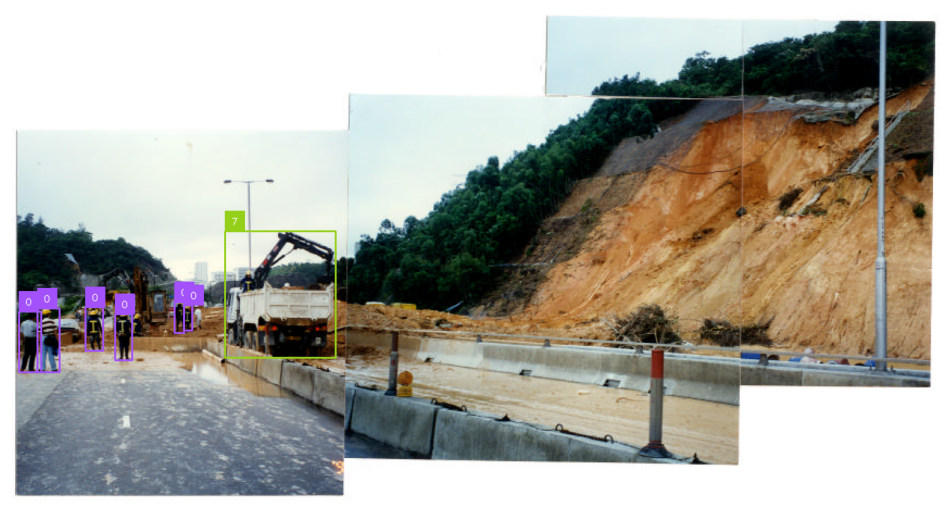

In [ ]:
import cv2
import supervision as sv
from ultralytics import YOLOv10

model = YOLOv10(f'{HOME}/weights/yolov10m.pt')
image = cv2.imread(f'/content/Ching_Cheung_Road1.png')
results = model(image, conf=0.25)[0]
detections = sv.Detections.from_ultralytics(results)

bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

## Download dataset from Roboflow Universe

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QmXFUUhawBQ9VfJb52PM")
project = rf.workspace("horacelo").project("cdg-colluvium")
version = project.version(2)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CDG-colluvium-2 in folder:: 100%|██████████| 428/428 [00:00<00:00, 5532.58it/s]


## Custom Training for object detection

> Add blockquote



In [ ]:
%cd {HOME}
from ultralytics import YOLOv10
!yolo task=detect mode=train epochs=25 batch=8 plots=True \
model={HOME}/weights/yolov10n.pt \
data={dataset.location}/data.yaml

/content
New https://pypi.org/project/ultralytics/8.2.63 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=/content/weights/yolov10n.pt, data=/content/Landslide-scar-1/data.yaml, epochs=25, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, val_period=1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, r

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml  weights


/content


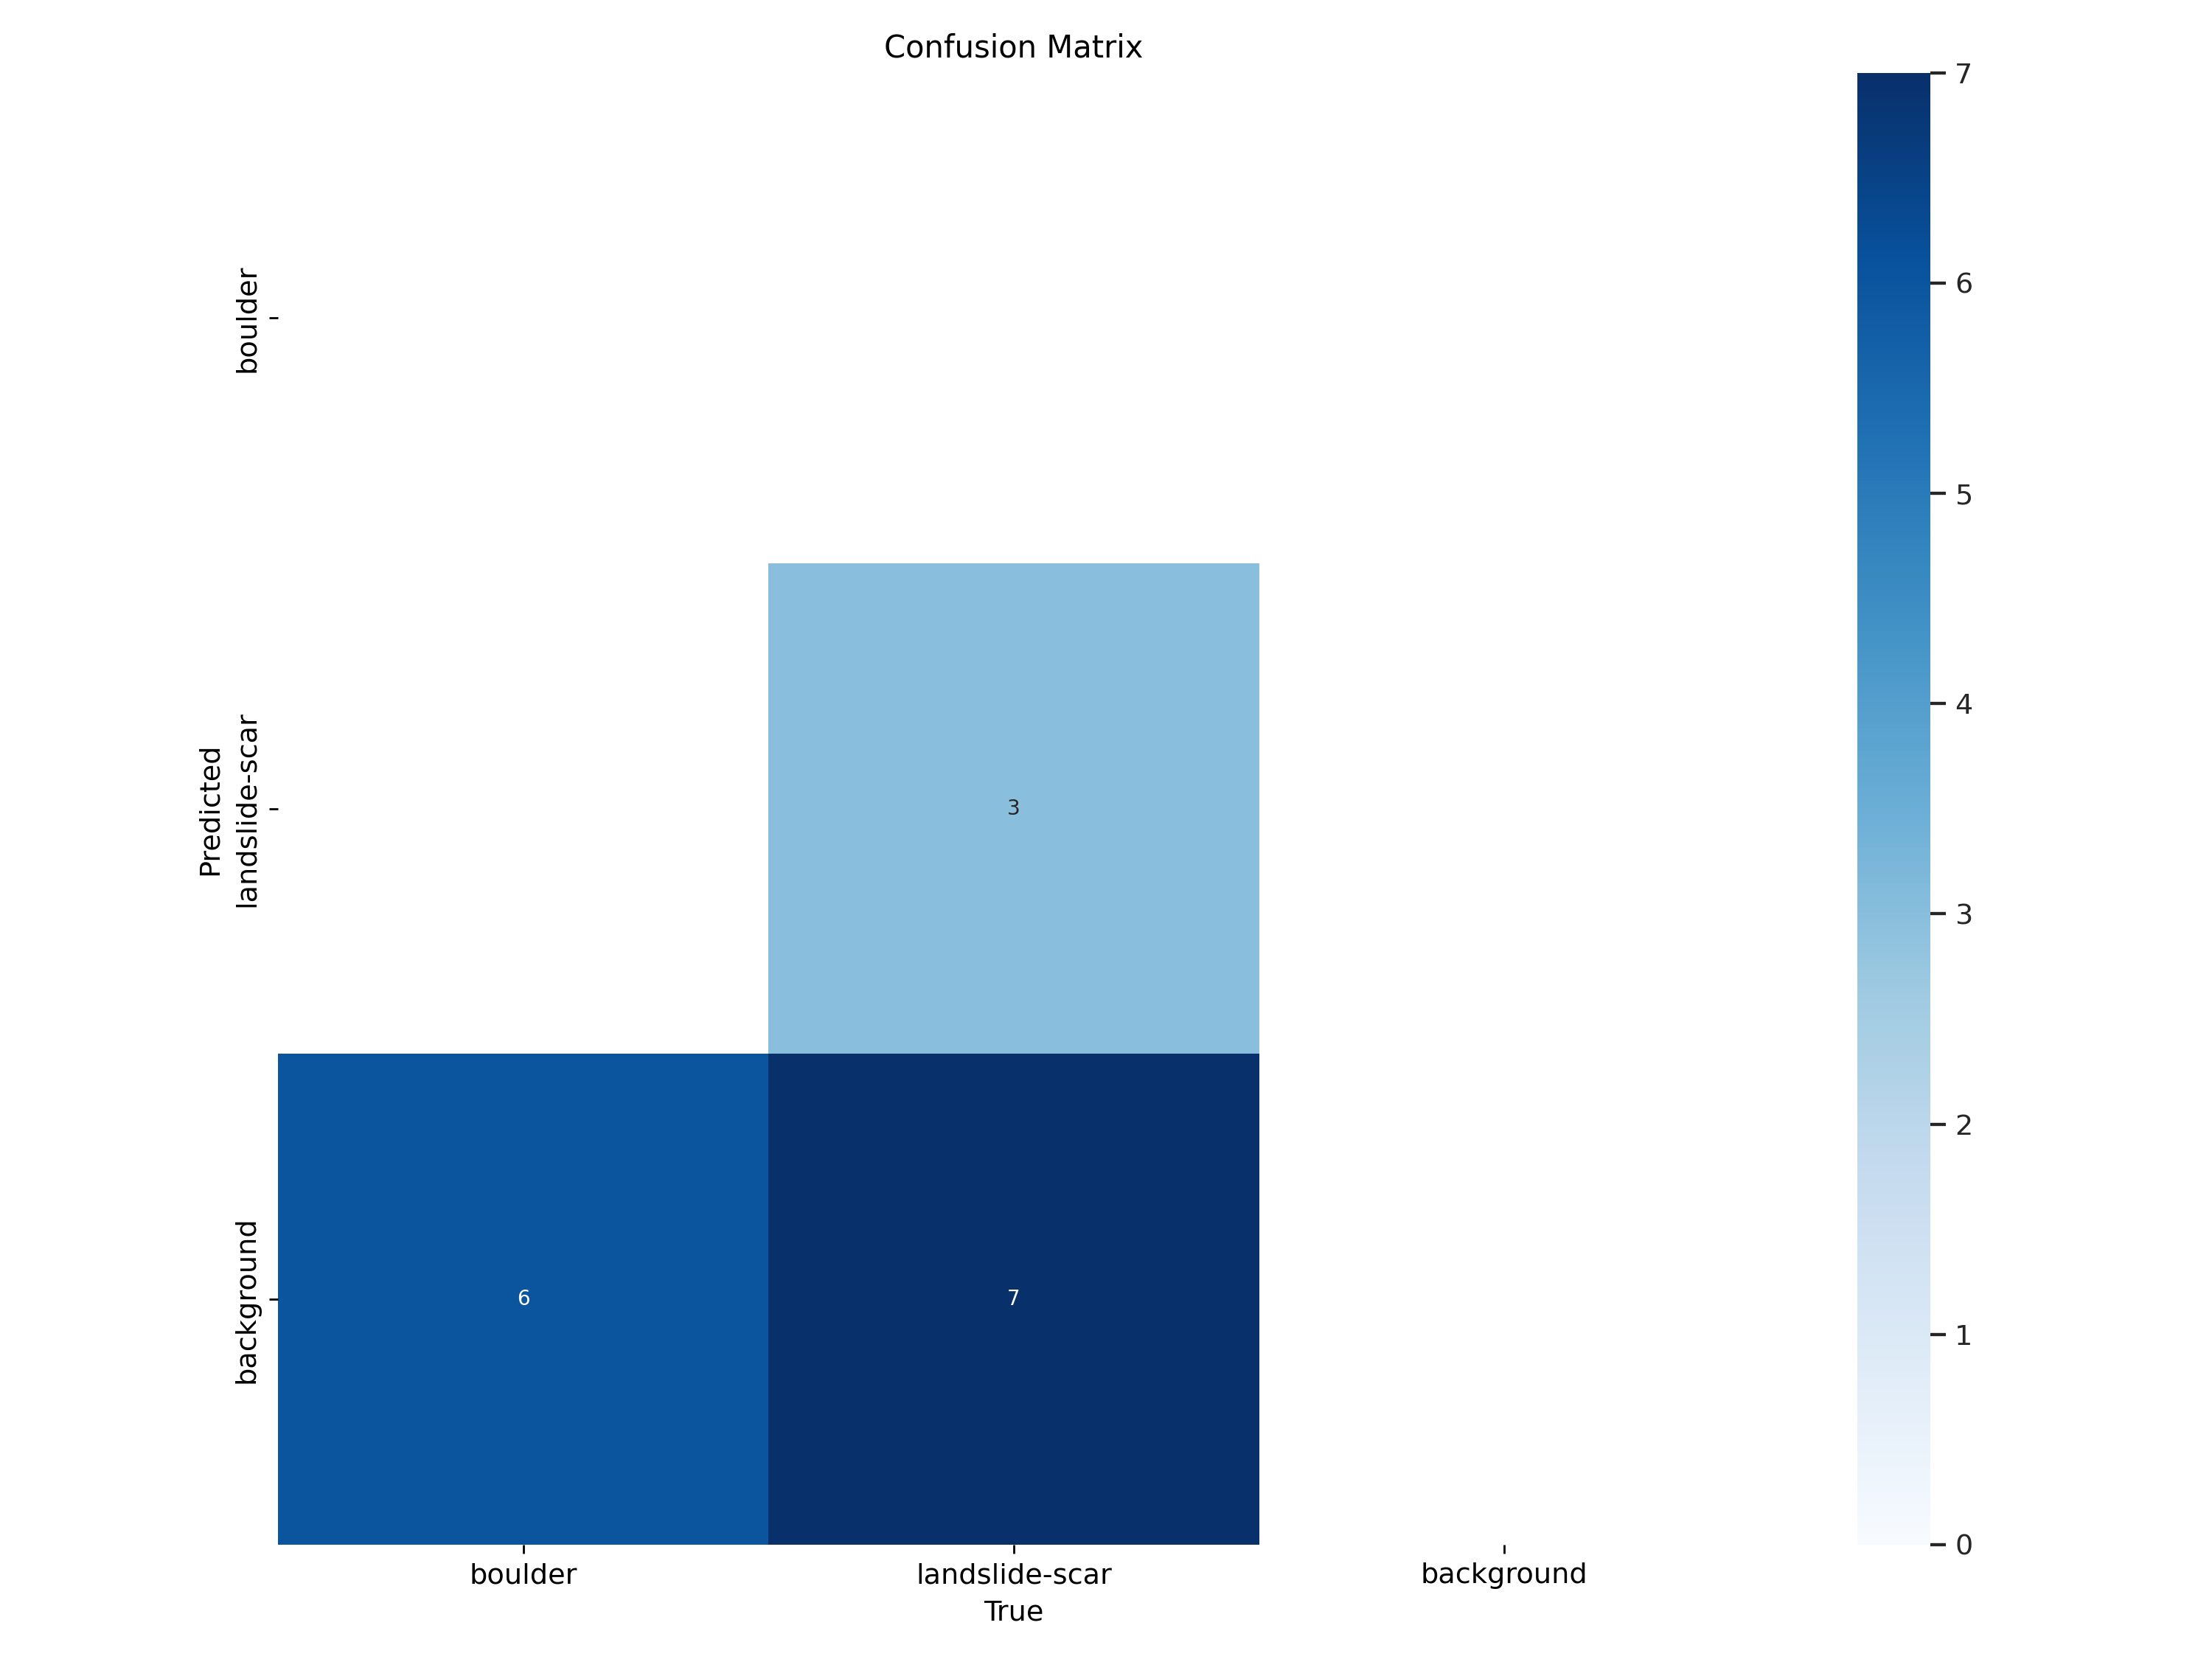

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


NameError: name 'Image' is not defined

Prediction with trained weights

In [ ]:
import cv2
import supervision as sv
from ultralytics import YOLOv10
model = YOLOv10(f'{HOME}/runs/detect/train/weights/best.pt')
image = cv2.imread(f'/content/Test1.png')
results = model(image, conf=0.15)[0]
detections = sv.Detections.from_ultralytics(results)

bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

print(results.boxes.xyxy)
print(results.boxes.conf)
print(results.boxes.cls)

Output hidden; open in https://colab.research.google.com to view.

Custom training for image classification

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QmXFUUhawBQ9VfJb52PM")
project = rf.workspace("horacelo").project("cdg-colluvium")
version = project.version(2)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CDG-colluvium-2 in folder:: 100%|██████████| 428/428 [00:00<00:00, 5368.53it/s]


In [ ]:
from ultralytics import YOLO
# Load a model
#model = YOLO("yolov8m-cls.yaml")  # build a new model from YAML
model = YOLO("yolov8m-cls.pt")  # load a pretrained model (recommended for training)
#model = YOLO("yolov8m-cls.yaml").load("yolov8m-cls.pt")  # build from YAML and transfer weights

YOLOv8m-cls summary: 141 layers, 17053336 parameters, 17053336 gradients, 41.9 GFLOPs


100%|██████████| 32.7M/32.7M [00:00<00:00, 74.3MB/s]


Transferred 230/230 items from pretrained weights


In [ ]:
# Train the model
results = model.train(data="/content/CDG-colluvium-2", epochs=100, imgsz=64)

New https://pypi.org/project/ultralytics/8.2.67 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=classify, mode=train, model=yolov8m-cls.yaml, data=/content/CDG-colluvium-2, epochs=100, time=None, patience=100, batch=16, imgsz=64, save=True, save_period=-1, val_period=1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None,

100%|██████████| 6.23M/6.23M [00:00<00:00, 136MB/s]


AMP: checks passed ✅


train: Scanning /content/CDG-colluvium-2/train... 363 images, 0 corrupt: 100%|██████████| 363/363 [00:00<00:00, 940.14it/s]

train: New cache created: /content/CDG-colluvium-2/train.cache


...

    100/100     0.895G    0.05322         11         64: 100%|██████████| 23/23 [00:02<00:00, 11.45it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 2/2 [00:00<00:00, 21.37it/s]

                   all      0.706          1



100 epochs completed in 0.104 hours.
Optimizer stripped from runs/classify/train/weights/last.pt, 31.7MB
Optimizer stripped from runs/classify/train/weights/best.pt, 31.7MB

Validating runs/classify/train/weights/best.pt...
Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-cls summary (fused): 103 layers, 15766499 parameters, 0 gradients, 41.6 GFLOPs
train: /content/CDG-colluvium-2/train... found 363 images in 3 classes ✅ 
val: /content/CDG-colluvium-2/val... found 34 images in 3 classes ✅ 
test: /content/CDG-colluvium-2/test... found 17 images in 3 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 2/2 [00:00<00:00, 11.25it/s]


                   all      0.853          1
Speed: 0.0ms preprocess, 0.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/train
Results saved to runs/classify/train


In [ ]:
# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.top1  # top1 accuracy
metrics.top5  # top5 accuracy

Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-cls summary (fused): 103 layers, 15766499 parameters, 0 gradients, 41.6 GFLOPs
train: /content/CDG-colluvium-2/train... found 363 images in 3 classes ✅ 
val: /content/CDG-colluvium-2/val... found 34 images in 3 classes ✅ 
test: /content/CDG-colluvium-2/test... found 17 images in 3 classes ✅ 


val: Scanning /content/CDG-colluvium-2/val... 34 images, 0 corrupt: 100%|██████████| 34/34 [00:00<?, ?it/s]
os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
               classes   top1_acc   top5_acc: 100%|██████████| 3/3 [00:00<00:00,  4.85it/s]


                   all      0.853          1
Speed: 0.1ms preprocess, 7.5ms inference, 0.4ms loss, 0.0ms postprocess per image
Results saved to runs/classify/train2


os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


1.0

In [ ]:
#Prediction with trained weights
from ultralytics import YOLO
model = YOLO("best.pt")  # load a trained model

In [ ]:
results = model(f'/content/CDG-colluvium-2/val/CDG')


image 1/11 /content/CDG-colluvium-2/val/CDG/43276-C233-TP4-10a_png.rf.f65f3ceff989aa1bc1f69b35c41ec65c.jpg: 64x64 CDG 0.84, RS 0.16, Colluvium 0.00, 5.4ms
image 2/11 /content/CDG-colluvium-2/val/CDG/43276-C233-TP4-10b_png.rf.969af63e899fc5eda11cf89f6f1852ae.jpg: 64x64 CDG 1.00, RS 0.00, Colluvium 0.00, 5.7ms
image 3/11 /content/CDG-colluvium-2/val/CDG/43277-C217-TP4-10b-Copy_png.rf.9de8a4f64acdddb4351033fec5da022a.jpg: 64x64 CDG 1.00, Colluvium 0.00, RS 0.00, 5.2ms
image 4/11 /content/CDG-colluvium-2/val/CDG/43277-C218-TP2-10b_png.rf.e4c47881dc851a6a80c8c54f03472fd3.jpg: 64x64 CDG 1.00, RS 0.00, Colluvium 0.00, 5.4ms
image 5/11 /content/CDG-colluvium-2/val/CDG/43403-C217-DH1-12-Copy_png.rf.88163119fab220a8b659766c8a1342ab.jpg: 64x64 CDG 1.00, RS 0.00, Colluvium 0.00, 5.7ms
image 6/11 /content/CDG-colluvium-2/val/CDG/43403-C217-DH2-4-Copy_png.rf.3c157e48a4dee4c4c528ddd84fbf0066.jpg: 64x64 CDG 1.00, Colluvium 0.00, RS 0.00, 5.3ms
image 7/11 /content/CDG-colluvium-2/val/CDG/43403-C217-DH

In [ ]:
import numpy as np
prob_array = np.empty([0, 3])

In [ ]:
for r in results:
    print(r.probs.cpu().data.numpy())
    np.append(prob_array, r.probs.cpu().data.numpy(), axis=0)

[    0.83538  0.00016085     0.16446]


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

Train your own custom segmentation model

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QmXFUUhawBQ9VfJb52PM")
project = rf.workspace("horacelo").project("scar-segment")
version = project.version(2)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
loading Roboflow workspace...
loading Roboflow project...
[WARNING] we noticed you are downloading a `yolov8` datasets but you don't have `ultralytics` installed. Roboflow `.deploy` supports only models trained with `ultralytics==8.0.196`, to intall it `pip install ultralytics==8.0.196`.



Extracting Dataset Version Zip to scar-segment-2 in yolov8:: 100%|██████████| 304/304 [00:00<00:00, 2499.35it/s]


In [ ]:
from ultralytics import YOLO
# Load a model
model = YOLO("yolov8n-seg.pt")  # load a pretrained model (recommended for training)

100%|██████████| 6.73M/6.73M [00:00<00:00, 111MB/s]


In [ ]:
# Train the model
results = model.train(data="/content/scar-segment-2/data.yaml", epochs=100, imgsz=640)

New https://pypi.org/project/ultralytics/8.2.73 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/scar-segment-2/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, val_period=1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embe

100%|██████████| 755k/755k [00:00<00:00, 107MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 6.23M/6.23M [00:00<00:00, 280MB/s]


AMP: checks passed ✅


...

    100/100      2.73G     0.3763     0.8012     0.4119     0.9356          2        640: 100%|██████████| 9/9 [00:05<00:00,  1.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.42it/s]

                   all         12         25      0.724       0.59      0.619      0.287      0.692      0.583      0.565      0.233



100 epochs completed in 0.149 hours.
Optimizer stripped from runs/segment/train/weights/last.pt, 6.8MB
Optimizer stripped from runs/segment/train/weights/best.pt, 6.8MB

Validating runs/segment/train/weights/best.pt...
Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n-seg summary (fused): 195 layers, 3258454 parameters, 0 gradients, 12.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.29it/s]


                   all         12         25      0.781      0.677      0.676      0.308      0.701      0.622      0.562      0.226
      landslide-debris         12          9      0.702      0.667      0.635       0.29      0.574      0.556      0.525      0.164
   landslide-scar-C0N7         12         16       0.86      0.688      0.717      0.326      0.827      0.688        0.6      0.287
Speed: 0.3ms preprocess, 8.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/segment/train


## Segmentation Prediction with trained weights

In [6]:
#Prediction with trained weights
from ultralytics import YOLO
model = YOLO("/content/best.pt")  # load a trained model

/usr/local/lib/python3.10/dist-packages/ultralytics/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


In [7]:
results = model("/content/Kwun Lung Lau landslide.png", conf=0.2)



image 1/1 /content/Kwun Lung Lau landslide.png: 480x640 1 landslide-debris, 1 landslide-scar-C0N7, 46.9ms
image 1/1 /content/Kwun Lung Lau landslide.png: 480x640 1 landslide-debris, 1 landslide-scar-C0N7, 46.9ms
Speed: 14.2ms preprocess, 46.9ms inference, 740.9ms postprocess per image at shape (1, 3, 480, 640)
Speed: 14.2ms preprocess, 46.9ms inference, 740.9ms postprocess per image at shape (1, 3, 480, 640)


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


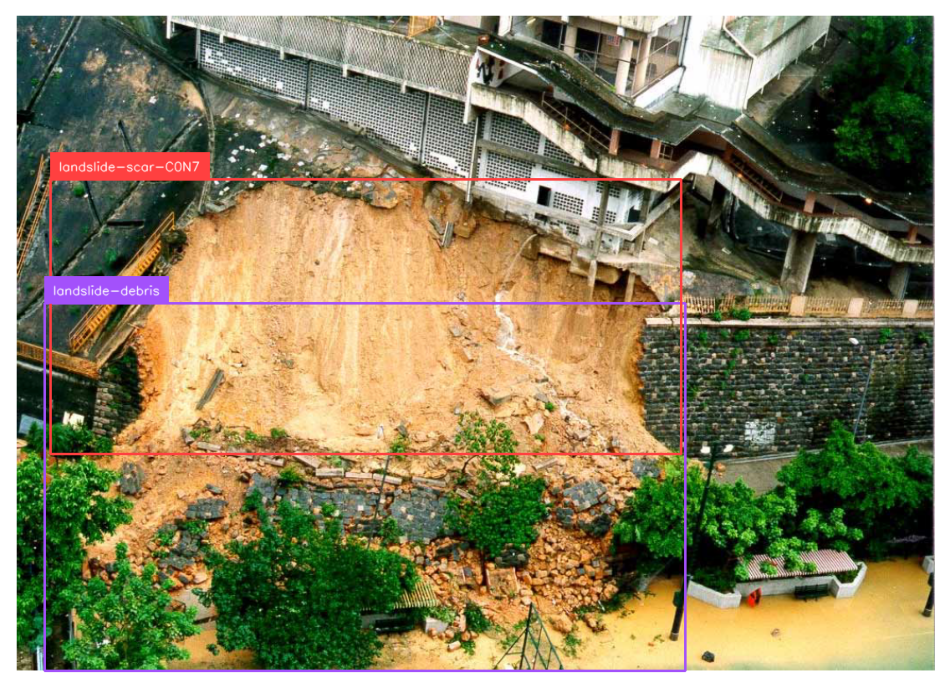

In [8]:
import cv2
import supervision as sv

image = cv2.imread(f"/content/Kwun Lung Lau landslide.png")
detections = sv.Detections.from_ultralytics(results[0])

bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

In [ ]:
import numpy as np
prob_array = np.empty([0, 2])
for r in results:
    print(r.probs.cpu().data.numpy())
    np.append(prob_array, r.probs.cpu().data.numpy(), axis=0)
print(prob_array)

In [ ]:
# Process results list
i=1
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    print(probs)
    result.show()  # display to screen
    result.save(filename="/content/output/result"+str(i)+".jpg")  # save to disk
    i=i+1

None


In [ ]:
!zip -r /content/output.zip /content/output

NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

In [ ]:
#Output box info and save them
import numpy as np
box_array = np.empty([0, 6])
i=1
for r in results:
    print(r.boxes.cpu().data.numpy())
    np.append(box_array, r.boxes.cpu().data.numpy(), axis=0)
print(box_array)

[[     6.0745      64.168      625.46      627.25     0.55207           1]
 [     4.9168      504.53      325.12      633.93     0.24455           0]
 [     138.36      16.677      553.16      545.73     0.22258           1]]
[[     183.53      191.35      423.47      552.97     0.43614           1]
 [          0      257.04      627.86      631.11     0.41419           0]
 [      15.35      189.48      419.48      558.37      0.3563           1]]
[[     289.68      74.431       634.4      456.11     0.88161           1]
 [     186.85      378.46      482.48       457.8     0.20397           0]]
[[     9.0066      110.36      627.09      632.87     0.79291           1]
 [     10.986      165.41         628      633.58     0.65913           0]]
[[     1.1786      70.003      341.64      475.55     0.73919           1]]
[[     2.4037      11.371      556.19      546.01     0.93328           1]
 [     573.12      306.19      639.78      533.84     0.75891           0]]
[[     220.93      

In [ ]:
import pandas as pd
df = pd.DataFrame(box_array)
# Save the dataframe to a CSV file
df.to_csv('boxdata.csv', index=False)

In [ ]:
print(results[2].masks.cpu().xyn[0])

[[    0.98906     0.12656]
 [    0.98906     0.12812]
 [    0.97031     0.14687]
 [    0.96875     0.14687]
 [    0.96719     0.14844]
 [    0.96562     0.14844]
 [    0.96406        0.15]
 [    0.96094        0.15]
 [    0.95938     0.15156]
 [    0.95469     0.15156]
 [    0.95312        0.15]
 [    0.95156        0.15]
 [    0.94844     0.14687]
 [    0.94687     0.14687]
 [    0.94687     0.14844]
 [    0.94531        0.15]
 [    0.94531     0.15781]
 [    0.94375     0.15937]
 [    0.94375     0.16406]
 [    0.94219     0.16563]
 [    0.94219     0.16875]
 [    0.93906     0.17188]
 [    0.93906     0.17344]
 [     0.9375       0.175]
 [     0.9375     0.17812]
 [    0.93281     0.18281]
 [    0.93125     0.18281]
 [    0.92969     0.18438]
 [    0.92656     0.18438]
 [      0.925     0.18594]
 [    0.92188     0.18594]
 [    0.92031      0.1875]
 [    0.91875      0.1875]
 [    0.91719     0.18906]
 [    0.91562     0.18906]
 [    0.91406     0.19062]
 [    0.90781     0.19062]
 

In [ ]:
import numpy as np
print(results[1].boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 0., 1.], device='cuda:0')
conf: tensor([0.4361, 0.4142, 0.3563], device='cuda:0')
data: tensor([[1.8353e+02, 1.9135e+02, 4.2347e+02, 5.5297e+02, 4.3614e-01, 1.0000e+00],
        [0.0000e+00, 2.5704e+02, 6.2786e+02, 6.3111e+02, 4.1419e-01, 0.0000e+00],
        [1.5350e+01, 1.8948e+02, 4.1948e+02, 5.5837e+02, 3.5630e-01, 1.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([3, 6])
xywh: tensor([[303.5011, 372.1616, 239.9401, 361.6167],
        [313.9305, 444.0757, 627.8609, 374.0737],
        [217.4165, 373.9238, 404.1337, 368.8925]], device='cuda:0')
xywhn: tensor([[0.4742, 0.5815, 0.3749, 0.5650],
        [0.4905, 0.6939, 0.9810, 0.5845],
        [0.3397, 0.5843, 0.6315, 0.5764]], device='cuda:0')
xyxy: tensor([[183.5310, 191.3533, 423.4711, 552.9700],
        [  0.0000, 257.0389, 627.8609, 631.1126],
        [ 15.3497, 189.4776, 419.4833, 558.3701]], device='cuda:0')


In [ ]:
from ultralytics import YOLOv10
# Load a model
modelpre = YOLOv10("yolov10m.pt")  # load a pretrained model (recommended for training)

In [ ]:
results = modelpre("/content/scar-segment-2/valid/images/Ching-Cheung-Road-1_png.rf.17ddbf7ff9d68e60a560d887761433de.jpg", conf=0.15)


image 1/1 /content/scar-segment-2/valid/images/Ching-Cheung-Road-1_png.rf.17ddbf7ff9d68e60a560d887761433de.jpg: 640x640 6 0s, 37.9ms
Speed: 2.8ms preprocess, 37.9ms inference, 68.1ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
# Process results list
i=1
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    print(probs)
    result.show()  # display to screen
    result.save(filename="/content/output/result"+str(i)+".jpg")  # save to disk
    i=i+1

None
